<a href="https://colab.research.google.com/github/cconsta1/DentalAgeClassification-scripts/blob/main/DentalAge_4thRevision_Inference_20260325.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# 4th Revision -- 25 March 2026
# Dental Age Classification: Inference-Only Notebook
#
# Tasks addressed:
#   1) Figure 5 (internal validation only):
#      4 rows x 3 columns (PAN | EfficientNetV2 Grad-CAM | ViT Occlusion).
#      Prioritises cases where BOTH models misclassify the same image.
#      Wrong predictions rendered in bold. Layout matches Figure 4.
#
#   2) Table 4: Binary predictions obtained by thresholding regression
#      outputs and multiclass age predictions at 18 years.
#      Rows for BOTH internal test AND Brazilian external validation,
#      with 95% bootstrap confidence intervals.
#      For multiclass models, ROC AUC is computed from hard binary outputs
#      since class-probability estimates are not used.
#
# No training is performed. All weights come from saved .pth files.
# =============================================================================

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import re
import glob
from PIL import Image
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device.")

Using cuda device.


In [3]:
age_min, age_max = 14, 24
age2class = {age: idx for idx, age in enumerate(range(age_min, age_max + 1))}
class2age = {v: k for k, v in age2class.items()}
n_classes = len(age2class)


def normalize_age(age):
    return (age - age_min) / (age_max - age_min)


def denormalize_age(norm_age):
    return norm_age * (age_max - age_min) + age_min


def get_transforms(backbone='efficientnet'):
    """Validation-only transforms (no augmentation)."""
    img_size = 224 if backbone == 'vit' else 384
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

In [4]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        q = self.query(x).unsqueeze(1)
        k = self.key(x).unsqueeze(1)
        v = self.value(x).unsqueeze(1)
        attn_weights = self.softmax(
            torch.bmm(q, k.transpose(1, 2)) / (x.size(1) ** 0.5))
        return torch.bmm(attn_weights, v).squeeze(1)


class DentalAgeModel(nn.Module):
    def __init__(self, task_type='binary', backbone='efficientnet',
                 use_attention=True):
        super().__init__()
        self.task_type = task_type
        self.backbone_type = backbone
        self.use_attention = use_attention

        if backbone == 'efficientnet':
            self.backbone = models.efficientnet_v2_s(
                weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
            self.backbone.classifier = nn.Identity()
            self.feature_dim = 1280
        elif backbone == 'vit':
            self.backbone = models.vit_b_16(
                weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
            self.backbone.heads = nn.Identity()
            self.feature_dim = 768

        if use_attention:
            self.attention = SelfAttention(self.feature_dim)

        if task_type in ['binary', 'regression']:
            self.fc1 = nn.Linear(self.feature_dim, 256)
            self.bn1 = nn.BatchNorm1d(256)
            self.dropout1 = nn.Dropout(0.2)
            self.fc2 = nn.Linear(256, 128)
            self.bn2 = nn.BatchNorm1d(128)
            self.dropout2 = nn.Dropout(0.2)
            self.fc3 = nn.Linear(128, 1)
        elif task_type == 'multiclass':
            self.fc1 = nn.Linear(self.feature_dim, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.dropout1 = nn.Dropout(0.25)
            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.dropout2 = nn.Dropout(0.25)
            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.dropout3 = nn.Dropout(0.25)
            self.fc4 = nn.Linear(128, n_classes)

    def forward(self, x):
        features = self.backbone(x)
        if self.use_attention:
            features = self.attention(features)

        if self.task_type == 'multiclass':
            x = self.dropout1(F.relu(self.bn1(self.fc1(features))))
            x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
            x = self.dropout3(F.relu(self.bn3(self.fc3(x))))
            return self.fc4(x)
        else:
            x = self.dropout1(F.relu(self.bn1(self.fc1(features))))
            x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
            x = self.fc3(x).squeeze(1)
            return torch.sigmoid(x)

In [5]:
class DentalAgeDataset(Dataset):
    def __init__(self, dataframe, transform, task_type='binary'):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.task_type = task_type

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('L').convert('RGB')
        img = self.transform(img)

        if self.task_type == 'binary':
            label = 1 if int(row['age']) >= 18 else 0
        elif self.task_type == 'multiclass':
            label = age2class[int(row['age'])]
        elif self.task_type == 'regression':
            label = np.float32(row['age_norm'])
        return img, label

In [6]:
BASE_DIR = "/content/drive/MyDrive/DentalAgeClassification"


def load_model(model_name):
    model_dir = os.path.join(BASE_DIR, model_name)
    with open(os.path.join(model_dir, "config.json"), "r") as f:
        config = json.load(f)

    task_type = config['task_type']
    backbone = config['backbone']
    use_attention = (backbone == 'efficientnet')

    model = DentalAgeModel(task_type=task_type, backbone=backbone,
                           use_attention=use_attention).to(device)
    model.load_state_dict(torch.load(
        os.path.join(model_dir, "model.pth"), map_location=device))
    model.eval()

    val_df = pd.read_pickle(os.path.join(model_dir, "val_df.pkl"))
    print(f"Loaded {model_name} | task={task_type}  backbone={backbone}  "
          f"val_samples={len(val_df)}")
    return model, config, val_df

In [7]:
def predict_binary(model, df, backbone):
    """Binary model inference. Returns DataFrame with true, pred, prob columns."""
    val_transform = get_transforms(backbone=backbone)
    dataset = DentalAgeDataset(df, val_transform, task_type='binary')
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    preds, trues, probs = [], [], []
    model.eval()
    with torch.no_grad():
        for img, label in loader:
            img = img.to(device)
            out = model(img).item()
            probs.append(out)
            preds.append(1 if out >= 0.5 else 0)
            trues.append(label.item())

    result = df.copy()
    result['true'] = trues
    result['pred'] = preds
    result['prob'] = probs
    result['correct'] = (result['true'] == result['pred'])
    return result


def predict_regression_as_binary(model, df, backbone):
    """
    Run regression model, denormalize predicted age, threshold at 18.
    Returns (y_true, y_pred, y_score).
    y_score is the continuous normalised prediction (used for ROC AUC).
    """
    work_df = df.copy()
    if 'age_norm' not in work_df.columns:
        work_df['age_norm'] = normalize_age(work_df['age'].astype(float))

    val_transform = get_transforms(backbone=backbone)
    dataset = DentalAgeDataset(work_df, val_transform, task_type='regression')
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    scores = []
    model.eval()
    with torch.no_grad():
        for img, _ in loader:
            img = img.to(device)
            scores.append(model(img).item())

    scores = np.array(scores)
    pred_ages = denormalize_age(scores)
    y_pred = (pred_ages >= 18).astype(int)
    y_true = (work_df['age'].values.astype(int) >= 18).astype(int)
    return y_true, y_pred, scores


def predict_multiclass_as_binary(model, df, backbone):
    """
    Run multiclass model, map predicted class to age, threshold at 18.
    Returns (y_true, y_pred, y_score).
    y_score is hard binary (0/1) because class-probability estimates
    are not used for AUC (see Table 4 caption).
    """
    work_df = df.copy()
    if 'age_norm' not in work_df.columns:
        work_df['age_norm'] = normalize_age(work_df['age'].astype(float))

    val_transform = get_transforms(backbone=backbone)
    dataset = DentalAgeDataset(work_df, val_transform, task_type='multiclass')
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    pred_classes = []
    model.eval()
    with torch.no_grad():
        for img, _ in loader:
            img = img.to(device)
            out = model(img)
            pred_classes.append(out.argmax(dim=1).item())

    pred_ages = np.array([class2age[c] for c in pred_classes])
    y_pred = (pred_ages >= 18).astype(int)
    y_true = (work_df['age'].values.astype(int) >= 18).astype(int)
    return y_true, y_pred, y_pred.astype(float)

In [8]:
def _gradcam_heatmap(model, img_tensor):
    """GradCAM heatmap for EfficientNet backbone. Returns 2-D numpy array."""
    from pytorch_grad_cam import GradCAM

    target_layers = [model.backbone.features[-1]]

    class SimpleTarget:
        def __call__(self, output):
            if isinstance(output, torch.Tensor):
                if output.dim() == 0 or output.shape == torch.Size([1]):
                    return output
                return torch.max(output)
            return output

    cam = GradCAM(model=model, target_layers=target_layers)
    return cam(input_tensor=img_tensor, targets=[SimpleTarget()])[0]


def _occlusion_heatmap(model, img_tensor, img_size):
    """Occlusion sensitivity map for ViT backbone. Returns 2-D numpy array."""
    import cv2
    patch_size = 16
    n_patches = img_size // patch_size
    sensitivity = np.zeros((n_patches, n_patches))

    model.eval()
    with torch.no_grad():
        baseline = model(img_tensor).item()

    for h in range(n_patches):
        for w in range(n_patches):
            occ = img_tensor.clone()
            occ[0, :, h*patch_size:(h+1)*patch_size,
                      w*patch_size:(w+1)*patch_size] = 0
            with torch.no_grad():
                occ_pred = model(occ).item()
            sensitivity[h, w] = abs(baseline - occ_pred)

    sensitivity = (sensitivity - sensitivity.min()) / \
                  (sensitivity.max() - sensitivity.min() + 1e-8)
    return cv2.resize(sensitivity, (img_size, img_size))

In [9]:
def create_figure5(cases, model_eff, model_vit, suptitle, filename):
    """
    N rows x 3 cols: PAN | EfficientNet Grad-CAM | ViT Occlusion.
    One case per row. Wrong predictions rendered in bold.
    Column headers placed above the figure to avoid collision with row labels.
    """
    import cv2

    n = len(cases)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4.0 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, case in enumerate(cases):
        row   = case['row']
        label = case['label']

        fp       = row['filepath'].values[0]
        true_age = int(row['age'].values[0])
        true_bin = int(row['true'].values[0])
        eff_p    = int(row['eff_pred'].values[0])
        vit_p    = int(row['vit_pred'].values[0])

        true_str  = "Adult" if true_bin == 1 else "Minor"
        eff_str   = "Adult" if eff_p == 1 else "Minor"
        vit_str   = "Adult" if vit_p == 1 else "Minor"
        eff_wrong = (eff_p != true_bin)
        vit_wrong = (vit_p != true_bin)

        img_pil = Image.open(fp).convert('L').convert('RGB')

        # EfficientNet Grad-CAM
        eff_tf     = get_transforms(backbone='efficientnet')
        eff_tensor = eff_tf(img_pil).unsqueeze(0).to(device)
        eff_img    = np.array(img_pil.resize((384, 384))) / 255.0
        gradcam    = _gradcam_heatmap(model_eff, eff_tensor)
        if gradcam.shape != (384, 384):
            gradcam = cv2.resize(gradcam, (384, 384))

        # ViT Occlusion
        vit_tf     = get_transforms(backbone='vit')
        vit_tensor = vit_tf(img_pil).unsqueeze(0).to(device)
        vit_img    = np.array(img_pil.resize((224, 224))) / 255.0
        occ_map    = _occlusion_heatmap(model_vit, vit_tensor, 224)

        # Col 0: Original PAN with row label
        axes[i, 0].imshow(img_pil, cmap='gray')
        axes[i, 0].set_title(
            f"{label}\nTrue: {true_str} (Age {true_age})",
            fontsize=10, pad=8)
        axes[i, 0].axis('off')

        # Col 1: Grad-CAM overlay
        axes[i, 1].imshow(eff_img)
        axes[i, 1].imshow(gradcam, alpha=0.5, cmap='jet')
        axes[i, 1].set_title(
            f"Pred: {eff_str}", fontsize=10, pad=8,
            fontweight='bold' if eff_wrong else 'normal')
        axes[i, 1].axis('off')

        # Col 2: Occlusion overlay
        axes[i, 2].imshow(vit_img)
        axes[i, 2].imshow(occ_map, alpha=0.5, cmap='jet')
        axes[i, 2].set_title(
            f"Pred: {vit_str}", fontsize=10, pad=8,
            fontweight='bold' if vit_wrong else 'normal')
        axes[i, 2].axis('off')

    # Layout first, then add column headers via fig.text to avoid overlap
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    col_headers = [
        "Panoramic Radiograph",
        "EfficientNetV2-S Grad-CAM",
        "ViT-B/16 Occlusion Sensitivity"
    ]
    for j, hdr in enumerate(col_headers):
        bbox = axes[0, j].get_position()
        fig.text(
            bbox.x0 + bbox.width / 2, 0.955, hdr,
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

In [10]:
def compute_diagnostic_indices(y_true, y_pred, y_score, n_boot=2000):
    """Returns (point_dict, ci_dict, (tn, fp, fn, tp))."""
    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    y_score = np.array(y_score, dtype=float)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    point = {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'F1 score':    f1_score(y_true, y_pred, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        point['ROC AUC'] = roc_auc_score(y_true, y_score)

    rng = np.random.RandomState(42)
    boots = {k: [] for k in point}

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        yt, yp, ys = y_true[idx], y_pred[idx], y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        cm_b = confusion_matrix(yt, yp)
        tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

        boots['Accuracy'].append(accuracy_score(yt, yp))
        boots['Sensitivity'].append(
            tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0)
        boots['Specificity'].append(
            tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0)
        boots['F1 score'].append(f1_score(yt, yp, zero_division=0))
        if 'ROC AUC' in point:
            try:
                boots['ROC AUC'].append(roc_auc_score(yt, ys))
            except ValueError:
                pass

    ci = {}
    for k in point:
        if boots.get(k):
            ci[k] = (np.percentile(boots[k], 2.5),
                     np.percentile(boots[k], 97.5))
        else:
            ci[k] = (np.nan, np.nan)

    return point, ci, (tn, fp, fn, tp)

In [11]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
import zipfile, shutil

zip_path_int = '/content/drive/MyDrive/DentAgePooledDatav2.zip'
local_zip_int = './DentAgePooledDatav2.zip'

if not os.path.exists('./DentAgePooledDatav2'):
    if not os.path.exists(local_zip_int):
        print("Copying internal dataset ZIP from Drive...")
        with open(zip_path_int, 'rb') as src, open(local_zip_int, 'wb') as dst:
            shutil.copyfileobj(src, dst, length=1024*1024)
        print("Copy complete.")
    print("Extracting...")
    with zipfile.ZipFile(local_zip_int, 'r') as z:
        z.extractall('.')
    print("Extraction complete.")
else:
    print("Internal dataset already extracted.")

Copying internal dataset ZIP from Drive...
Copy complete.
Extracting...
Extraction complete.


In [13]:
import zipfile, shutil

zip_path     = '/content/drive/MyDrive/Brazilian Dental Panoramic X-Ray Dataset.zip'
local_zip    = '/content/Brazilian_dataset.zip'
dataset_path = '/content/Brazilian_dataset'

if not os.path.exists(local_zip):
    print("Copying Brazilian dataset ZIP from Drive...")
    shutil.copy2(zip_path, local_zip)

if not os.path.exists(dataset_path):
    print("Extracting...")
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall('/content')
    extracted = [d for d in os.listdir('/content')
                 if os.path.isdir(os.path.join('/content', d)) and 'Brazilian' in d]
    if extracted and not os.path.exists(dataset_path):
        os.rename(os.path.join('/content', extracted[0]), dataset_path)
    print("Extraction complete.")

dfs = []
for csv_name in ['train.csv', 'val.csv', 'test.csv']:
    csv_path = os.path.join(dataset_path, csv_name)
    if os.path.exists(csv_path):
        dfs.append(pd.read_csv(csv_path))
brazilian_all = pd.concat(dfs, ignore_index=True)

brazilian_all['filepath'] = brazilian_all['path'].apply(
    lambda x: os.path.join(dataset_path, x))
brazilian_all['age'] = np.round(brazilian_all['age_in_years']).astype(int)

brazilian_df = brazilian_all[
    (brazilian_all['age'] >= age_min) &
    (brazilian_all['age'] <= age_max)].copy()
brazilian_df['bin_label'] = (brazilian_df['age'] >= 18).astype(int)
brazilian_df['age_norm']  = normalize_age(brazilian_df['age'].astype(float))

print(f"Brazilian dataset: {len(brazilian_df)} samples (age {age_min}-{age_max})")
print(brazilian_df['age'].value_counts().sort_index())

Copying Brazilian dataset ZIP from Drive...
Extracting...
Extraction complete.
Brazilian dataset: 1579 samples (age 14-24)
age
14    151
15    111
16    120
17    106
18    175
19    141
20    149
21    118
22    164
23    152
24    192
Name: count, dtype: int64


In [14]:
# ---- Figure 5: load binary models and run on internal validation set -------
model_eff, cfg_eff, val_df = load_model("binary_efficientnet_aug")
model_vit, cfg_vit, _      = load_model("binary_vit_aug")

preds_eff = predict_binary(model_eff, val_df, backbone="efficientnet")
preds_vit = predict_binary(model_vit, val_df, backbone="vit")

combined_int = val_df.copy()
combined_int['true']     = preds_eff['true'].values
combined_int['eff_pred'] = preds_eff['pred'].values
combined_int['eff_prob'] = preds_eff['prob'].values
combined_int['vit_pred'] = preds_vit['pred'].values
combined_int['vit_prob'] = preds_vit['prob'].values

# Priority: cases where BOTH models give the wrong answer
both_fp = combined_int[
    (combined_int['true'] == 0) &
    (combined_int['eff_pred'] == 1) &
    (combined_int['vit_pred'] == 1)]
both_fn = combined_int[
    (combined_int['true'] == 1) &
    (combined_int['eff_pred'] == 0) &
    (combined_int['vit_pred'] == 0)]

# Fallback: at least one model wrong
any_fp = combined_int[
    (combined_int['true'] == 0) &
    ((combined_int['eff_pred'] == 1) | (combined_int['vit_pred'] == 1))]
any_fn = combined_int[
    (combined_int['true'] == 1) &
    ((combined_int['eff_pred'] == 0) | (combined_int['vit_pred'] == 0))]

print("Cases where BOTH models misclassify:")
print(f"  False Adult (FP): {len(both_fp)}")
print(f"  False Minor (FN): {len(both_fn)}")
print("Cases where at least one model misclassifies:")
print(f"  False Adult (FP): {len(any_fp)}")
print(f"  False Minor (FN): {len(any_fn)}")

# Use both-model pool when available, otherwise fall back
use_both = (len(both_fp) > 0) and (len(both_fn) > 0)
if use_both:
    fp_pool, fn_pool = both_fp, both_fn
    source_note = "BOTH models wrong on every selected case"
else:
    fp_pool, fn_pool = any_fp, any_fn
    source_note = "at least one model wrong (no both-model cases available)"

n_fp = min(2, len(fp_pool))
n_fn = min(2, len(fn_pool))
# If one category is short, fill from the other
if n_fp + n_fn < 4:
    if n_fp < 2:
        n_fn = min(4 - n_fp, len(fn_pool))
    else:
        n_fp = min(4 - n_fn, len(fp_pool))

fp_sel = fp_pool.sample(n=n_fp, random_state=42) if n_fp > 0 else pd.DataFrame()
fn_sel = fn_pool.sample(n=n_fn, random_state=42) if n_fn > 0 else pd.DataFrame()

cases_fig5 = []
letter = iter(['(a)', '(b)', '(c)', '(d)'])
for i in range(len(fp_sel)):
    cases_fig5.append({
        'row':   fp_sel.iloc[[i]],
        'label': f'{next(letter)} False Adult (FP)'})
for i in range(len(fn_sel)):
    cases_fig5.append({
        'row':   fn_sel.iloc[[i]],
        'label': f'{next(letter)} False Minor (FN)'})

print(f"\nSelection strategy: {source_note}")
print(f"Figure 5 will show {len(cases_fig5)} cases:")
for c in cases_fig5:
    r = c['row']
    print(f"  {c['label']}: Age {int(r['age'].values[0])}, "
          f"True={int(r['true'].values[0])}, "
          f"Eff={int(r['eff_pred'].values[0])}, "
          f"ViT={int(r['vit_pred'].values[0])}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 215MB/s]


Loaded binary_efficientnet_aug | task=binary  backbone=efficientnet  val_samples=353
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 196MB/s]


Loaded binary_vit_aug | task=binary  backbone=vit  val_samples=353
Cases where BOTH models misclassify:
  False Adult (FP): 4
  False Minor (FN): 11
Cases where at least one model misclassifies:
  False Adult (FP): 22
  False Minor (FN): 27

Selection strategy: BOTH models wrong on every selected case
Figure 5 will show 4 cases:
  (a) False Adult (FP): Age 16, True=0, Eff=1, ViT=1
  (b) False Adult (FP): Age 17, True=0, Eff=1, ViT=1
  (c) False Minor (FN): Age 18, True=1, Eff=0, ViT=0
  (d) False Minor (FN): Age 18, True=1, Eff=0, ViT=0


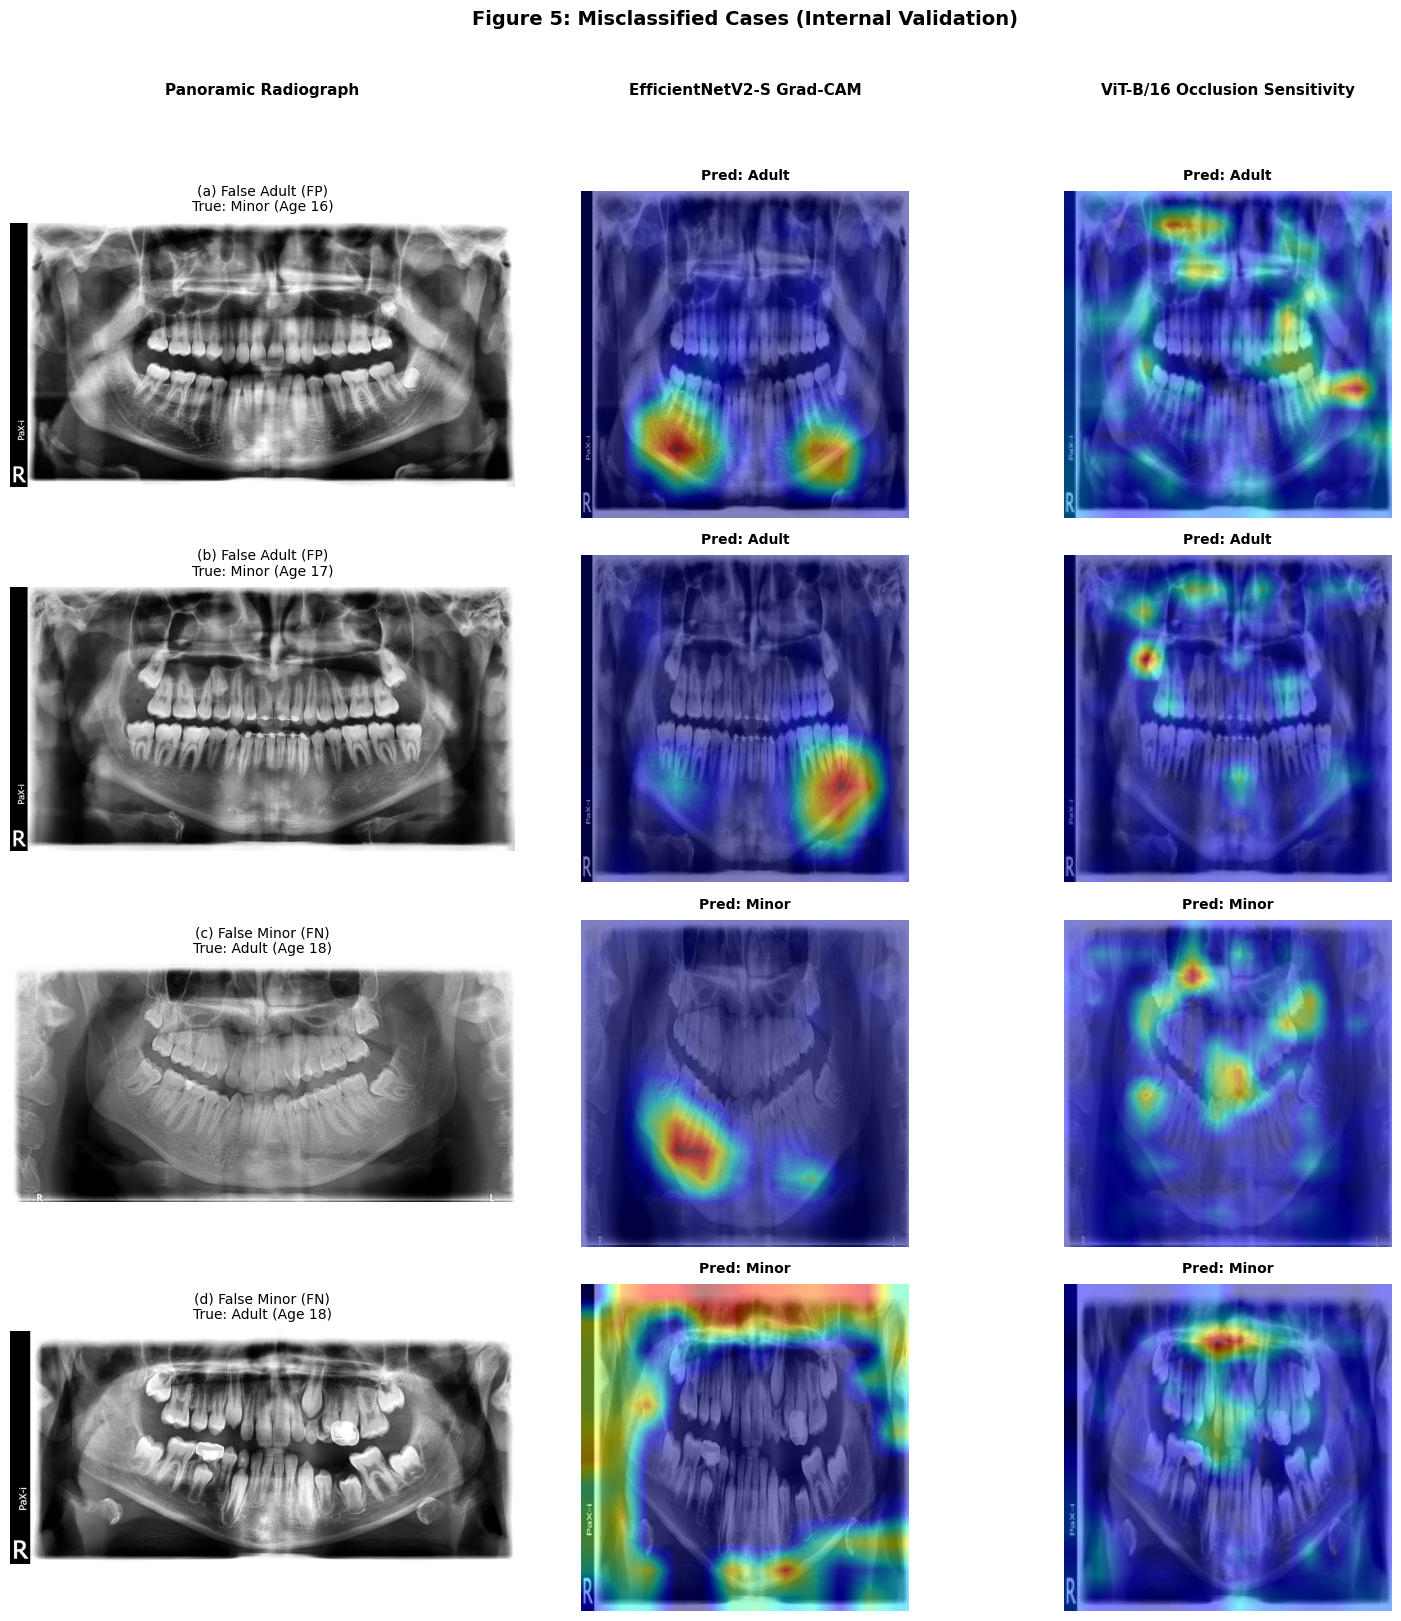

Saved: 4rev_figure5_internal.png


In [15]:
fig5 = create_figure5(
    cases_fig5, model_eff, model_vit,
    suptitle="Figure 5: Misclassified Cases (Internal Validation)",
    filename="4rev_figure5_internal.png")
print("Saved: 4rev_figure5_internal.png")

In [16]:
# ---- Table 4: threshold regression/multiclass predictions at age 18 -------
# Model directory names -- adjust if yours differ
model_specs = [
    ('regression_efficientnet_aug',  'EfficientNetV2', 'Regression'),
    ('regression_vit_aug',           'ViT',            'Regression'),
    ('multiclass_efficientnet_aug',  'EfficientNetV2', 'Multiclass'),
    ('multiclass_vit_aug',           'ViT',            'Multiclass'),
]

table_rows = []

for model_name, backbone_label, source_task in model_specs:
    mdl, cfg, mdl_val_df = load_model(model_name)
    backbone  = cfg['backbone']
    task_type = cfg['task_type']

    # Ensure age_norm exists on internal val_df
    if 'age_norm' not in mdl_val_df.columns:
        mdl_val_df['age_norm'] = normalize_age(mdl_val_df['age'].astype(float))

    predict_fn = (predict_regression_as_binary if task_type == 'regression'
                  else predict_multiclass_as_binary)

    # -- Internal validation --
    yt_int, yp_int, ys_int = predict_fn(mdl, mdl_val_df, backbone)
    pt_int, ci_int, cm_int = compute_diagnostic_indices(yt_int, yp_int, ys_int)
    table_rows.append({
        'Dataset': 'Internal test', 'Backbone': backbone_label,
        'Source_task': source_task, 'Aug': 'Yes',
        'point': pt_int, 'ci': ci_int, 'cm': cm_int})

    # -- Brazilian external validation --
    yt_br, yp_br, ys_br = predict_fn(mdl, brazilian_df, backbone)
    pt_br, ci_br, cm_br = compute_diagnostic_indices(yt_br, yp_br, ys_br)
    table_rows.append({
        'Dataset': 'Brazilian ext.', 'Backbone': backbone_label,
        'Source_task': source_task, 'Aug': 'Yes',
        'point': pt_br, 'ci': ci_br, 'cm': cm_br})

    print()

Loaded regression_efficientnet_aug | task=regression  backbone=efficientnet  val_samples=353

Loaded regression_vit_aug | task=regression  backbone=vit  val_samples=353

Loaded multiclass_efficientnet_aug | task=multiclass  backbone=efficientnet  val_samples=353

Loaded multiclass_vit_aug | task=multiclass  backbone=vit  val_samples=353



In [17]:
# ---- Format and display Table 4 -------------------------------------------
metrics_order = ['Accuracy', 'Sensitivity', 'Specificity', 'F1 score', 'ROC AUC']

# Build a flat list for pandas
rows_flat = []
for r in table_rows:
    row_dict = {
        'Dataset':     r['Dataset'],
        'Backbone':    r['Backbone'],
        'Source task':  r['Source_task'],
        'Aug':         r['Aug'],
    }
    for m in metrics_order:
        v = r['point'].get(m, np.nan)
        lo, hi = r['ci'].get(m, (np.nan, np.nan))
        row_dict[m] = round(v, 2) if not np.isnan(v) else np.nan
        row_dict[f"{m} 95% CI"] = (
            f"{lo:.4f}-{hi:.4f}" if not np.isnan(lo) else '--')
    tn, fp, fn, tp = r['cm']
    row_dict.update({'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})
    rows_flat.append(row_dict)

table4_df = pd.DataFrame(rows_flat)

# Print compact version matching paper style
print("=" * 100)
print("TABLE 4 -- Binary predictions by thresholding at 18 years")
print("         (Internal test + Brazilian external validation, 95% CIs)")
print("=" * 100)
compact_cols = ['Dataset', 'Backbone', 'Source task', 'Aug'] + metrics_order
print(table4_df[compact_cols].to_string(index=False))

# Save full version with CIs to CSV
table4_df.to_csv("4rev_table4_diagnostic_indices.csv", index=False)
print("\nSaved: 4rev_table4_diagnostic_indices.csv")

# Print full version with CIs
print("\nFull table with 95% bootstrap CIs:")
print(table4_df.to_string(index=False))

TABLE 4 -- Binary predictions by thresholding at 18 years
         (Internal test + Brazilian external validation, 95% CIs)
       Dataset       Backbone Source task Aug  Accuracy  Sensitivity  Specificity  F1 score  ROC AUC
 Internal test EfficientNetV2  Regression Yes      0.85         0.84         0.87      0.86     0.93
Brazilian ext. EfficientNetV2  Regression Yes      0.86         0.92         0.72      0.90     0.91
 Internal test            ViT  Regression Yes      0.83         0.77         0.90      0.83     0.92
Brazilian ext.            ViT  Regression Yes      0.82         0.86         0.74      0.87     0.88
 Internal test EfficientNetV2  Multiclass Yes      0.84         0.77         0.93      0.84     0.85
Brazilian ext. EfficientNetV2  Multiclass Yes      0.80         0.84         0.72      0.86     0.78
 Internal test            ViT  Multiclass Yes      0.73         0.55         0.96      0.69     0.75
Brazilian ext.            ViT  Multiclass Yes      0.59         0.45

In [18]:
print("=" * 60)
print("4th Revision -- Output Summary (25 March 2026)")
print("=" * 60)
print()
print("Figure 5:")
print("  4rev_figure5_internal.png")
print("    4 rows x 3 columns (PAN | Grad-CAM | Occlusion).")
print("    Misclassified cases from internal validation only.")
print("    Prioritised cases where BOTH models are wrong.")
print("    Wrong predictions shown in bold.")
print()
print("Table 4:")
print("  4rev_table4_diagnostic_indices.csv")
print("    Binary predictions by thresholding regression/multiclass")
print("    outputs at 18 years. Includes both Internal test and")
print("    Brazilian external validation rows with 95% bootstrap CIs.")
print("    For multiclass models, ROC AUC was computed from hard")
print("    binary outputs (class-probability estimates not used).")

4th Revision -- Output Summary (25 March 2026)

Figure 5:
  4rev_figure5_internal.png
    4 rows x 3 columns (PAN | Grad-CAM | Occlusion).
    Misclassified cases from internal validation only.
    Prioritised cases where BOTH models are wrong.
    Wrong predictions shown in bold.

Table 4:
  4rev_table4_diagnostic_indices.csv
    Binary predictions by thresholding regression/multiclass
    outputs at 18 years. Includes both Internal test and
    Brazilian external validation rows with 95% bootstrap CIs.
    For multiclass models, ROC AUC was computed from hard
    binary outputs (class-probability estimates not used).
